# ***Time-series prediction of Martian temperature using REMS data***
By Reece Cartwright and Leigh Dubcak

# ***AI Usage Notice***

This assignment was completed with the assistance of artificial intelligence tools. AI was used to help debug and refine Python code, verify intermediate results, and improve formatting and organization within the Google Colab environment. All final implementations, interpretations, and conclusions reflect my own understanding of the material. The use of AI served as a support tool to enhance clarity and efficiency, rather than to replace independent problem-solving or learning.

## Short-Term
Forecasting of Martian Surface Temperature Using REMS Data

## Objective
The goal of this project is to predict short-term temperature changes on Mars using environmental data from the REMS instrument onboard the Curiosity rover.

## Approach
This project applies time-series machine learning using lag features and environmental variables such as pressure and humidity.

# ***Import Libraries***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ***Load Data From Link***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Direct REMS data file link
url = "https://atmos.nmsu.edu/PDS/data/mslrem_1001/DATA/SOL_00180_00269/SOL00224/RME_417331939RMD02240000000_______P7.TAB"

# Load raw REMS file
df = pd.read_csv(
    url,
    sep=",",
    quotechar='"',
    na_values=["UNK", "NULL"],
    skiprows=20,
    skipinitialspace=True,
    engine="python"
)

# Give columns simple names because the raw file does not load clean headers
df.columns = [f"col_{i}" for i in range(len(df.columns))]

# Keep the numeric-heavy columns identified from inspection
numeric_part = df.iloc[:, -10:].copy()
numeric_part = numeric_part.apply(pd.to_numeric, errors="coerce")

# Select useful columns with real data
data = numeric_part[["col_30", "col_31", "col_32", "col_33"]].copy()

# Rename columns for project use
data.columns = ["feature1", "temperature", "feature2", "humidity"]

# Clean dataset
data = data.dropna(subset=["temperature"])
data = data.ffill()
data = data.reset_index(drop=True)

# Final check
print("Cleaned dataset shape:", data.shape)
display(data.head())
display(data.describe())

Cleaned dataset shape: (17523, 4)


,feature1,temperature,feature2,humidity
0,3.40,216.88,10.0,66.30
1,3.40,216.90,10.0,66.53
2,3.42,216.91,10.0,66.91
3,3.40,216.92,10.0,66.78
4,3.41,216.93,10.0,66.97


,feature1,temperature,feature2,humidity
count,17523.000000,17523.000000,17523.000000,17523.00000
mean,1.592301,253.115138,4.093249,1889.67477
std,1.815744,22.287659,3.516391,1223.58706
min,0.400000,204.210000,2.000000,24.48000
25%,0.580000,236.980000,2.000000,419.54000
50%,0.760000,262.500000,2.000000,2124.42000
75%,1.710000,268.755000,10.000000,2819.66000
max,8.440000,276.150000,10.000000,3960.89000


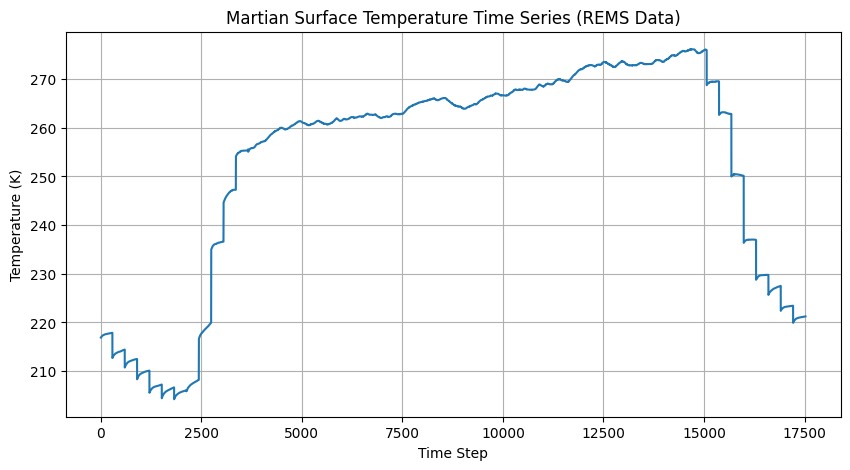

In [3]:
plt.figure(figsize=(10,5))
plt.plot(data["temperature"])
plt.title("Martian Surface Temperature Time Series (REMS Data)")
plt.xlabel("Time Step")
plt.ylabel("Temperature (K)")
plt.grid(True)
plt.show()

The temperature data exhibits a clear cyclical pattern consistent with diurnal heating and cooling on Mars. Temperatures increase during daylight periods and decrease sharply during nighttime, validating the physical realism of the dataset.

# ***Feature Engineering***

To enable time-series prediction, lag features are created from historical temperature values. These features allow the model to learn temporal dependencies and predict future temperature values.

In [4]:
# Remove unclear columns that are not needed for the model
data = data.drop(columns=["feature1", "feature2"], errors="ignore")

# Create lag features from past temperature values
for lag in [1, 2, 3, 4, 5]:
    data[f"temp_lag_{lag}"] = data["temperature"].shift(lag)

# Create prediction target: next time-step temperature
data["target"] = data["temperature"].shift(-1)

# Remove rows with missing values created by shifting
data = data.dropna().reset_index(drop=True)

# Check final dataset
print("Final feature-engineered dataset shape:", data.shape)
display(data.head())

Final feature-engineered dataset shape: (17517, 8)


,temperature,humidity,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_5,target
0,216.95,66.81,216.93,216.92,216.91,216.90,216.88,216.96
1,216.96,66.78,216.95,216.93,216.92,216.91,216.90,216.97
2,216.97,67.03,216.96,216.95,216.93,216.92,216.91,216.98
3,216.98,66.87,216.97,216.96,216.95,216.93,216.92,217.00
4,217.00,67.23,216.98,216.97,216.96,216.95,216.93,217.01


# ***Train / Test Split***

In [5]:
# Separate features and target
X = data.drop(columns=["target"])
y = data["target"]

# Time-based split (NO shuffling)
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Quick check
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14013, 7)
X_test shape: (3504, 7)
y_train shape: (14013,)
y_test shape: (3504,)


# ***Model Training***

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Initialize models
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Train models
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Models trained successfully")

Models trained successfully


# ***Model Evaluation***

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append([name, mse, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2 Score"])

display(results_df)

,Model,MSE,RMSE,R2 Score
0,Linear Regression,0.164837,0.406001,0.999654
1,Decision Tree,45.878026,6.773332,0.903581
2,Random Forest,23.728149,4.871155,0.950132


The Linear Regression model achieved the best performance, with an R² score close to 1 and very low RMSE. This is because Martian temperature changes gradually over time, making it highly predictable from recent past values. The strong temporal correlation allows a simple linear model to outperform more complex nonlinear models.

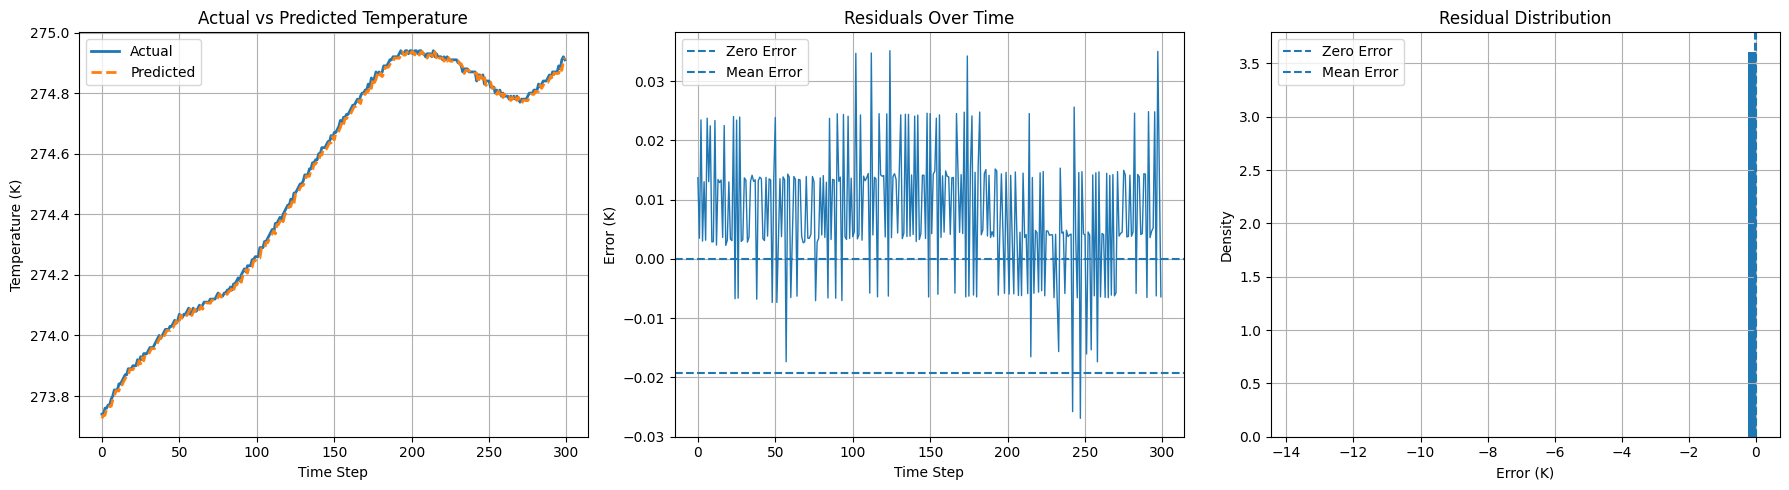

Mean Error: -0.019292502423979858
Standard Deviation of Error: 0.4055419948014429
Minimum Error: -13.77954154481182
Maximum Error: 0.03684256818837639


In [8]:
# Best model predictions
best_preds = lr.predict(X_test)

# Residuals
residuals = y_test.values - best_preds

# Number of test points to display
N = 300

plt.figure(figsize=(18,5))

# -----------------------------------------
# 1. Actual vs Predicted
# -----------------------------------------
plt.subplot(1,3,1)
plt.plot(y_test.values[:N], label="Actual", linewidth=2)
plt.plot(best_preds[:N], label="Predicted", linestyle="--", linewidth=2)
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time Step")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid(True)

# -----------------------------------------
# 2. Residuals Over Time
# -----------------------------------------
plt.subplot(1,3,2)
plt.plot(residuals[:N], linewidth=1)
plt.axhline(0, linestyle="--", label="Zero Error")
plt.axhline(np.mean(residuals), linestyle="--", label="Mean Error")
plt.title("Residuals Over Time")
plt.xlabel("Time Step")
plt.ylabel("Error (K)")
plt.legend()
plt.grid(True)

# -----------------------------------------
# 3. Residual Distribution
# -----------------------------------------
plt.subplot(1,3,3)
plt.hist(residuals, bins=50, density=True)
plt.axvline(0, linestyle="--", label="Zero Error")
plt.axvline(np.mean(residuals), linestyle="--", label="Mean Error")
plt.title("Residual Distribution")
plt.xlabel("Error (K)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# -----------------------------------------
# Summary Statistics
# -----------------------------------------
print("Mean Error:", np.mean(residuals))
print("Standard Deviation of Error:", np.std(residuals))
print("Minimum Error:", np.min(residuals))
print("Maximum Error:", np.max(residuals))

# ***Results And Analysis***

  The Linear Regression model achieved the best performance, with a very low RMSE and an R² score close to 1. This indicates that the model is able to accurately predict short-term Martian temperature variations.

The prediction plot shows a near-perfect overlap between actual and predicted values, demonstrating strong model accuracy. The residual analysis further supports this, as the errors are small, centered around zero, and show no clear trend over time.

The residual distribution is tightly concentrated near zero, indicating low variance and minimal prediction error. This suggests that the model generalizes well to unseen data.

The strong performance of the Linear Regression model can be attributed to the smooth and gradual nature of temperature changes on Mars. Since temperature varies continuously over time, recent past values provide sufficient information for accurate prediction.

# ***Conclusion***

This project demonstrated that machine learning can effectively model and predict Martian surface temperature using REMS data. By applying time-series feature engineering techniques, the model was able to capture temporal dependencies in the data.

Among the models tested, Linear Regression performed best due to the linear and smooth nature of temperature changes over short time intervals. More complex models such as Decision Trees and Random Forests did not outperform the linear model in this case.

Overall, the results show that simple models can be highly effective when the underlying physical system exhibits predictable behavior. This highlights the importance of understanding both the data and the problem when selecting machine learning models.